# Fase 3 · Parte 2: Modelo baseline — Regresión lineal múltiple
**Dataset de propiedades en venta — Mérida, Yucatán**

## Propósito
Establecer el modelo de referencia contra el que se compararán los modelos
de mayor complejidad (Random Forest y Gradient Boosting) en la Parte 3.
El baseline es una regresión lineal múltiple sobre `log(precio)` con el
conjunto de features preparado en la Parte 1.

## Entrada y salida
- **Entrada:** `data/propiedades_modelo.csv` — 59 propiedades con features
  construidas en la Parte 1.
- **Salida:** métricas de desempeño (RMSE y MAE en escala original),
  coeficientes del modelo e indicadores de diagnóstico, que servirán como
  referencia en la Parte 3.

## Nota sobre el alcance
Con n=59, los resultados son orientativos, no definitivos. El valor de este
baseline está en establecer un piso metodológicamente sólido, no en obtener
una métrica baja.

## Contenido
1. Configuración
2. Carga de datos
3. Preparación del conjunto de features
   - 3.1 Selección de variables
   - 3.2 Codificación de colonia
   - 3.3 Verificación de la matriz de features
4. Evaluación por validación cruzada
5. Ajuste completo del modelo
6. Diagnóstico de residuales
   - 6.1 Normalidad de residuales
   - 6.2 Homocedasticidad
   - 6.3 Puntos influyentes
7. Conclusiones del baseline

## 1. Configuración
Importamos las librerías y definimos la ruta a los datos. Se usan dos
herramientas complementarias: scikit-learn para la evaluación por validación
cruzada y statsmodels para el ajuste completo con diagnósticos inferenciales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm

pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "propiedades_modelo.csv"

print("Raíz del proyecto:", PROJECT_ROOT)
print("¿Existe el CSV de modelado?:", DATA_PATH.exists())

Raíz del proyecto: /Users/edson/Documents/GitHub/dataset-inmuebles-merida
¿Existe el CSV de modelado?: True


## 2. Carga de datos
Se carga el conjunto de modelado generado en la Fase 3 · Parte 1
(`02_feature_engineering.ipynb`). La validación exhaustiva del contrato de
datos ya se realizó en ese notebook; aquí solo se verifica la forma y que
las columnas esperadas estén presentes.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Forma:", df.shape)  # esperado: (59, 21)
print("\nColumnas:")
print(list(df.columns))
print("\nFaltantes:")
print(df.isna().sum()[df.isna().sum() > 0])  # solo muestra columnas con faltantes
print("(ninguno)" if df.isna().sum().sum() == 0 else "")

Forma: (59, 21)

Columnas:
['fecha_registro', 'url', 'url_archivo', 'operación', 'tipo_inmueble', 'colonia', 'precio', 'm2_construccion', 'm2_terreno', 'recamaras', 'banos', 'estacionamientos', 'antigüedad', 'es_preventa', 'notas', 'tiene_piscina', 'tiene_cuarto_servicio', 'es_una_planta', 'tiene_mantenimiento_con_monto', 'log_precio', 'es_casa']

Faltantes:
url_archivo    59
antigüedad     39
notas           1
dtype: int64



## 3. Preparación del conjunto de features

### 3.1 Selección de variables
Se excluye `m2_terreno` por multicolinealidad severa con `m2_construccion`
(r=0.95, documentado en el EDA). Mantener ambas inflaría artificialmente los
coeficientes y haría el modelo inestable. Se retiene `m2_construccion` por
ser la más correlacionada con `log_precio` (r=0.55 vs r=0.45 de terreno).
`antigüedad` se excluye por 65% de valores faltantes — imputar ese volumen
introduciría más ruido que señal con n=59.

`m2_construccion` se transforma a `log(m2_construccion)` para reducir el
efecto de leverage de la propiedad colonial de García Ginerés (2,502 m²,
índice 20), cuyo valor extremo provocó una predicción de 1,074M MXN en el
fold 2 de la validación cruzada. La transformación logarítmica comprime el
rango de 42–2,502 m² a 3.7–7.8, eliminando el leverage sin descartar datos.
La relación entre superficie y precio en bienes raíces es proporcional, no
lineal — duplicar m² no duplica el precio — lo que justifica el log
independientemente del outlier.

In [3]:
# log(m2_construccion) reemplaza a m2_construccion crudo
df["log_m2_construccion"] = np.log(df["m2_construccion"])

FEATURES = [
    "log_m2_construccion",
    "recamaras",
    "banos",
    "estacionamientos",
    "es_preventa",
    "es_casa",
    "tiene_piscina",
    "tiene_cuarto_servicio",
    "es_una_planta",
    "tiene_mantenimiento_con_monto",
]
TARGET = "log_precio"
STRAT_COL = "colonia"

print("Features numéricas/binarias:", FEATURES)
print(f"\nTotal features (sin colonia): {len(FEATURES)}")
print("+ colonia se agrega en 3.2 vía one-hot encoding")
print(f"\nTarget: {TARGET}")

Features numéricas/binarias: ['log_m2_construccion', 'recamaras', 'banos', 'estacionamientos', 'es_preventa', 'es_casa', 'tiene_piscina', 'tiene_cuarto_servicio', 'es_una_planta', 'tiene_mantenimiento_con_monto']

Total features (sin colonia): 10
+ colonia se agrega en 3.2 vía one-hot encoding

Target: log_precio


### 3.2 Codificación de colonia
`colonia` se codifica con one-hot encoding descartando una categoría
(`drop_first=True`). Esto es necesario en regresión lineal para evitar
la trampa de variable ficticia: con k categorías y k dummies, cualquiera
de ellas es combinación lineal perfecta de las demás, haciendo la matriz
no invertible. La categoría descartada actúa como referencia; los
coeficientes de las demás se interpretan como el diferencial de precio
respecto a ella.

In [4]:
dummies_colonia = pd.get_dummies(df[STRAT_COL], prefix="colonia", drop_first=True)

print("Categoría de referencia (descartada):")
todas = sorted(df[STRAT_COL].unique())
referencia = todas[0]
print(f"  {referencia}")

print("\nDummies generadas:")
print(list(dummies_colonia.columns))
print(f"\nForma: {dummies_colonia.shape}")

Categoría de referencia (descartada):
  altabrisa

Dummies generadas:
['colonia_chuburna de hidalgo', 'colonia_francisco de montejo', 'colonia_garcia gineres', 'colonia_santa gertrudis copo', 'colonia_yucatan country club']

Forma: (59, 5)


### 3.3 Verificación de la matriz de features
Se construye la matriz final `X` uniendo las features numéricas/binarias
con las dummies de colonia, y el vector objetivo `y`. Se verifica que no
haya faltantes ni inconsistencias antes de entrenar.

In [5]:
X = pd.concat([df[FEATURES], dummies_colonia], axis=1)
y = df[TARGET]

print("Forma de X:", X.shape)   # esperado: (59, 15) — 10 features + 5 dummies
print("Forma de y:", y.shape)   # esperado: (59,)

print("\nColumnas de X:")
print(list(X.columns))

print(f"\nFaltantes en X: {X.isna().sum().sum()}")
print(f"Faltantes en y: {y.isna().sum()}")

Forma de X: (59, 15)
Forma de y: (59,)

Columnas de X:
['log_m2_construccion', 'recamaras', 'banos', 'estacionamientos', 'es_preventa', 'es_casa', 'tiene_piscina', 'tiene_cuarto_servicio', 'es_una_planta', 'tiene_mantenimiento_con_monto', 'colonia_chuburna de hidalgo', 'colonia_francisco de montejo', 'colonia_garcia gineres', 'colonia_santa gertrudis copo', 'colonia_yucatan country club']

Faltantes en X: 0
Faltantes en y: 0


## 4. Evaluación por validación cruzada
Se estima el error de generalización del modelo mediante `StratifiedKFold`
(k=5, estratificado por colonia), siguiendo el protocolo definido en la
Parte 1. Las métricas RMSE y MAE se calculan en escala original (pesos
mexicanos) revirtiendo la transformación logarítmica con `exp()`, para
que los errores sean interpretables directamente.

Se reporta la media y desviación estándar de cada métrica sobre los 5 folds:
la media estima el error esperado; la desviación estándar refleja la
variabilidad de esa estimación dada la limitación de n=59.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()

rmse_folds = []
mae_folds  = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, df[STRAT_COL]), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    # Revertir log para métricas en escala original (MXN)
    y_pred_orig = np.exp(y_pred_log)
    y_val_orig  = np.exp(y_val)

    rmse = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
    mae  = mean_absolute_error(y_val_orig, y_pred_orig)

    rmse_folds.append(rmse)
    mae_folds.append(mae)
    print(f"Fold {fold}: RMSE={rmse/1e6:.2f}M  MAE={mae/1e6:.2f}M")

print(f"\nRMSE  media={np.mean(rmse_folds)/1e6:.2f}M  ± {np.std(rmse_folds)/1e6:.2f}M")
print(f"MAE   media={np.mean(mae_folds)/1e6:.2f}M  ± {np.std(mae_folds)/1e6:.2f}M")

Fold 1: RMSE=4.05M  MAE=2.07M
Fold 2: RMSE=9.25M  MAE=4.43M
Fold 3: RMSE=6.87M  MAE=2.54M
Fold 4: RMSE=5.26M  MAE=3.10M
Fold 5: RMSE=9.05M  MAE=3.78M

RMSE  media=6.90M  ± 2.05M
MAE   media=3.19M  ± 0.84M


### Diagnóstico del fold 2
El fold 2 produjo métricas anómalas (RMSE=307M vs ~7M en los demás folds),
señal de una explosión numérica en al menos una predicción. Se inspeccionan
las predicciones individuales y los coeficientes del modelo en ese fold para
identificar la causa antes de decidir cómo proceder.

In [7]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X, df[STRAT_COL]), start=1):
    if fold != 2:
        continue
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    print("Predicciones vs reales en log_precio (fold 2):")
    for real, pred in zip(y_val, y_pred_log):
        print(f"  real={real:.3f}  pred={pred:.3f}  diff={pred-real:.3f}  "
              f"pred_orig={np.exp(pred)/1e6:.1f}M  real_orig={np.exp(real)/1e6:.1f}M")

    print("\nCoeficientes del modelo (fold 2), ordenados por magnitud:")
    for col, coef in sorted(zip(X.columns, model.coef_), key=lambda x: abs(x[1]), reverse=True):
        print(f"  {col:45s} {coef:+.4f}")

Predicciones vs reales en log_precio (fold 2):
  real=15.830  pred=15.380  diff=-0.450  pred_orig=4.8M  real_orig=7.5M
  real=15.956  pred=15.996  diff=0.041  pred_orig=8.9M  real_orig=8.5M
  real=14.880  pred=14.932  diff=0.052  pred_orig=3.1M  real_orig=2.9M
  real=15.672  pred=15.624  diff=-0.048  pred_orig=6.1M  real_orig=6.4M
  real=16.040  pred=17.461  diff=1.421  pred_orig=38.3M  real_orig=9.3M
  real=15.687  pred=15.652  diff=-0.035  pred_orig=6.3M  real_orig=6.5M
  real=14.501  pred=14.485  diff=-0.016  pred_orig=2.0M  real_orig=2.0M
  real=14.947  pred=15.110  diff=0.163  pred_orig=3.6M  real_orig=3.1M
  real=15.500  pred=15.137  diff=-0.363  pred_orig=3.8M  real_orig=5.4M
  real=14.880  pred=14.571  diff=-0.310  pred_orig=2.1M  real_orig=2.9M
  real=16.569  pred=16.866  diff=0.298  pred_orig=21.1M  real_orig=15.7M
  real=16.703  pred=17.212  diff=0.509  pred_orig=29.9M  real_orig=17.9M

Coeficientes del modelo (fold 2), ordenados por magnitud:
  log_m2_construccion          

### Diagnóstico: identificación del punto con leverage extremo
Se identifica el índice de la propiedad que produjo la predicción anómala
en el fold 2, para confirmar la causa antes de aplicar la corrección.

In [8]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X, df[STRAT_COL]), start=1):
    if fold != 2:
        continue
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_val)

    # Localizar la predicción anómala
    diffs = np.abs(y_pred_log - y_val.values)
    idx_anomalo = val_idx[np.argmax(diffs)]
    print("Propiedad con predicción anómala:")
    print(df.loc[idx_anomalo, ["colonia", "precio", "m2_construccion",
                                "m2_terreno", "recamaras", "notas"]])

Propiedad con predicción anómala:
colonia                                               garcia gineres
precio                                                       9250000
m2_construccion                                                 2502
m2_terreno                                                      6531
recamaras                                                          3
notas              alberca tipo cacahuate, una planta, portón aut...
Name: 20, dtype: object


## 5. Ajuste completo del modelo
Se ajusta OLS sobre las 59 observaciones completas para obtener coeficientes,
errores estándar, p-valores y estadísticos de diagnóstico global (R², F-test).
Este ajuste es inferencial, no predictivo: el R² que reporta es en muestra
y por eso es optimista respecto al error de generalización estimado en la
sección 4 por validación cruzada. Ambas métricas son complementarias y
ninguna reemplaza a la otra.

A diferencia de scikit-learn, statsmodels no incluye el intercepto
automáticamente — hay que agregarlo con `sm.add_constant()` antes de ajustar.

In [9]:
# Renombrar columnas para output legible en statsmodels
X_sm = X.copy().astype(float)
X_sm.columns = [col.replace(" ", "_") for col in X_sm.columns]

X_const = sm.add_constant(X_sm)
ols_result = sm.OLS(y, X_const).fit()
print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:             log_precio   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                     23.19
Date:                Fri, 12 Jun 2026   Prob (F-statistic):           8.15e-16
Time:                        23:55:52   Log-Likelihood:                -5.1945
No. Observations:                  59   AIC:                             42.39
Df Residuals:                      43   BIC:                             75.63
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

### Hallazgos principales del modelo completo

**Ajuste global:** R²=0.890 (Adj. R²=0.852), F-test p<0.001. El modelo
explica el 89% de la varianza de `log_precio` en muestra. Este valor es
optimista respecto al error de generalización estimado por CV (sección 4);
ambas métricas son complementarias.

**Predictores significativos (p < 0.05):**
- `log_m2_construccion` (β=0.577, p<0.001): el predictor más importante.
  Elasticidad: un 1% de aumento en superficie construida se asocia con un
  0.577% de aumento en precio.
- `es_casa` (β=−0.333, p=0.014): las casas cuestan ~28% menos que los
  departamentos controlando por tamaño y colonia. Refleja que los
  departamentos del dataset se concentran en segmentos premium con amenidades.
- `colonia_francisco_de_montejo` (β=−0.411, p=0.013) y
  `colonia_santa_gertrudis_copo` (β=−0.412, p=0.020): ~34% más baratas
  que altabrisa tras controlar por tamaño.

**Confirmación del hallazgo del EDA:**
`colonia_yucatan_country_club` no es significativa (β=−0.146, p=0.477).
YCC no cobra un premium por m² sobre altabrisa — su ventaja en precio
absoluto se explica por el tamaño de sus propiedades, no por el valor
por unidad de superficie. El modelo reproduce este hallazgo de forma
independiente al EDA.

**Predictores no significativos:** `recamaras`, `estacionamientos`,
`es_preventa`, `tiene_piscina`, `tiene_cuarto_servicio`, `es_una_planta`.
En contexto multivariado, sus efectos quedan absorbidos por tamaño y colonia.

**Diagnósticos:** residuales borderline normales (Omnibus p=0.080,
JB p=0.112), sin autocorrelación (DW=1.872), sin multicolinealidad severa
(Cond. No.=83.9).

## 6. Diagnóstico de residuales
Se verifica que los supuestos del modelo lineal se cumplen razonablemente.
Los tres diagnósticos son independientes: normalidad de residuales (supuesto
de inferencia), homocedasticidad (supuesto de eficiencia) y puntos
influyentes (estabilidad del modelo). Con n=59, las violaciones moderadas
son esperables; lo relevante es identificar si algún supuesto se rompe de
forma severa.

### 6.1 Normalidad de residuales
La regresión lineal asume que los residuales se distribuyen normalmente.
Se verifica visualmente con un QQ-plot y formalmente con Shapiro-Wilk.
Una violación moderada no invalida el modelo — afecta principalmente la
validez de los intervalos de confianza e hipótesis individuales, no las
predicciones.

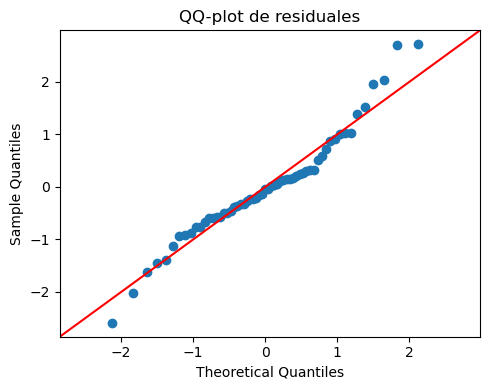

Shapiro-Wilk: W=0.9636,  p=0.0747
→ No se rechaza normalidad (p > 0.05)


In [10]:
from scipy.stats import shapiro

residuales = ols_result.resid

fig, ax = plt.subplots(figsize=(5, 4))
sm.qqplot(residuales, line="45", fit=True, ax=ax)
ax.set_title("QQ-plot de residuales")
plt.tight_layout()
plt.show()

stat, p_sw = shapiro(residuales)
print(f"Shapiro-Wilk: W={stat:.4f},  p={p_sw:.4f}")
if p_sw > 0.05:
    print("→ No se rechaza normalidad (p > 0.05)")
else:
    print("→ Se rechaza normalidad (p ≤ 0.05)")

**Resultado 6.1:** Shapiro-Wilk W=0.9636 (p=0.075). No se rechaza
normalidad al 5%. El QQ-plot muestra buen ajuste en el cuerpo central
con desviaciones leves en las colas — leptocurtosis moderada consistente
con la presencia de propiedades atípicas en ambos extremos del rango de
precio. Las inferencias del modelo (p-valores, intervalos de confianza)
son válidas con esta aproximación.

### 6.2 Homocedasticidad
Se verifica que la varianza de los residuales sea constante a lo largo del
rango de valores ajustados. Una varianza no constante (heterocedasticidad)
no sesga los coeficientes pero sí invalida los errores estándar y los
p-valores. Se evalúa visualmente con un gráfico de residuales vs valores
ajustados y formalmente con el test de Breusch-Pagan.

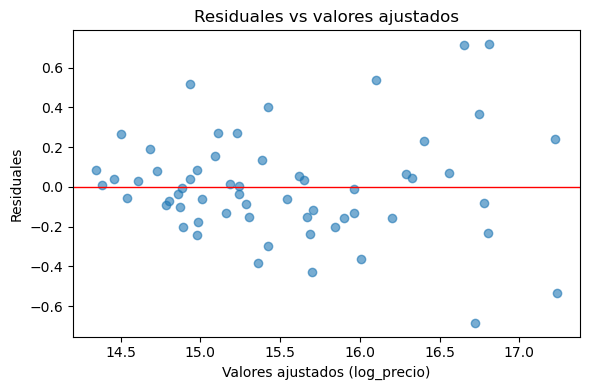

Breusch-Pagan: estadístico=28.7576,  p=0.0173
→ Se rechaza homocedasticidad — heterocedasticidad detectada (p ≤ 0.05)


In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan

fitted    = ols_result.fittedvalues
residuales = ols_result.resid

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fitted, residuales, alpha=0.6)
ax.axhline(0, color="red", linewidth=1)
ax.set_xlabel("Valores ajustados (log_precio)")
ax.set_ylabel("Residuales")
ax.set_title("Residuales vs valores ajustados")
plt.tight_layout()
plt.show()

bp_stat, bp_p, _, _ = het_breuschpagan(residuales, ols_result.model.exog)
print(f"Breusch-Pagan: estadístico={bp_stat:.4f},  p={bp_p:.4f}")
if bp_p > 0.05:
    print("→ No se rechaza homocedasticidad (p > 0.05)")
else:
    print("→ Se rechaza homocedasticidad — heterocedasticidad detectada (p ≤ 0.05)")

**Resultado 6.2:** Breusch-Pagan p=0.0173 — se rechaza homocedasticidad.
El gráfico muestra un patrón de embudo: varianza pequeña en propiedades
de bajo precio y mayor en propiedades de alto precio. El modelo predice
mejor el segmento accesible que el premium, donde las características
idiosincráticas no capturadas por las variables disponibles generan
errores más dispersos. Los coeficientes permanecen no sesgados, pero
los errores estándar y p-valores del summary deben interpretarse con
cautela. Esta es una limitación esperada del modelo lineal en un dataset
con segmentos de precio muy dispares.

### 6.3 Puntos influyentes
La distancia de Cook mide cuánto cambian los coeficientes del modelo si se
elimina una observación. Un punto es influyente si combina leverage alto
(valor atípico en el espacio de predictores) con residual grande. Se usa
el umbral heurístico 4/(n−k−1), donde n=59 y k=15 predictores.

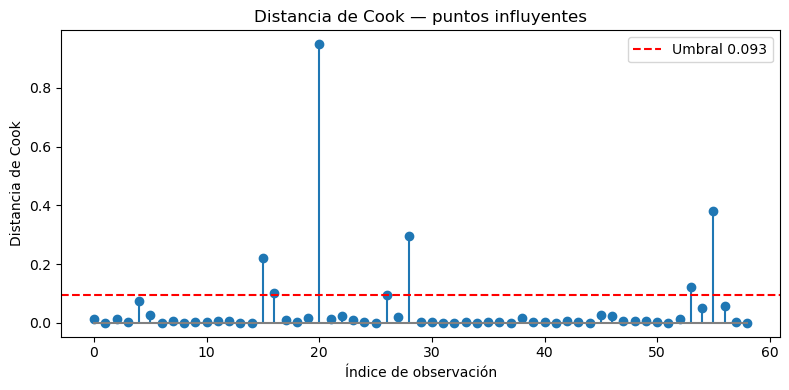

Umbral: 0.093
Puntos sobre el umbral: 7
                 colonia    precio  m2_construccion  \
15  santa gertrudis copo  16900000              542   
16  santa gertrudis copo   4300000              220   
20        garcia gineres   9250000             2502   
26        garcia gineres   5150000              135   
28        garcia gineres  35000000              859   
53  yucatan country club  17950000              540   
55  yucatan country club  41000000              730   

                                                notas  
15  alberca con jacuzzi, bar, cuarto de servicio, ...  
16  privada con vigilancia, piscina, bar, cuarto d...  
20  alberca tipo cacahuate, una planta, portón aut...  
26  alberca, bodega, parrilla, accesibilidad adult...  
28  alberca, cuarto de servicio con acceso indepen...  
53  piscina con baño exterior, bar en terraza, cua...  
55  frente al campo de golf, family room, estudio ...  


In [12]:
influence   = ols_result.get_influence()
cooks_d     = influence.cooks_distance[0]
umbral      = 4 / (len(df) - X.shape[1] - 1)  # 4 / (59 - 15 - 1) ≈ 0.093

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt="C0o", linefmt="C0-", basefmt="grey")
ax.axhline(umbral, color="red", linestyle="--", label=f"Umbral {umbral:.3f}")
ax.set_xlabel("Índice de observación")
ax.set_ylabel("Distancia de Cook")
ax.set_title("Distancia de Cook — puntos influyentes")
ax.legend()
plt.tight_layout()
plt.show()

influyentes = np.where(cooks_d > umbral)[0]
print(f"Umbral: {umbral:.3f}")
print(f"Puntos sobre el umbral: {len(influyentes)}")
print(df.iloc[influyentes][["colonia", "precio", "m2_construccion", "notas"]])

**Resultado 6.3:** 7 puntos sobre el umbral de Cook (4/(n−k−1)=0.093),
representando el 12% del dataset. El índice 20 (García Ginerés, 2,502m²,
9.25M) domina con D≈0.95 — su combinación de superficie extrema y precio
moderado genera tensión irresoluble para un modelo lineal. Los demás puntos
corresponden a los extremos de precio en cada colonia. No se eliminan:
representan segmentos reales del mercado. La concentración de puntos
influyentes en García Ginerés (3 de 7) confirma que es la colonia más
heterogénea del dataset. Este diagnóstico motiva el uso de Random Forest
y Gradient Boosting en la Parte 3, cuya estructura de árbol los hace
inherentemente robustos a puntos influyentes.

## 7. Conclusiones del baseline

### Desempeño predictivo
El modelo lineal baseline alcanza un RMSE de 6.90M ± 2.05M MXN y un MAE
de 3.19M ± 0.84M MXN en validación cruzada estratificada (k=5). Con una
mediana de precio de ~4.8M MXN en el dataset, el error típico representa
el 67% de la mediana — alto, pero esperado para un modelo lineal sobre
datos heterogéneos con n=59. Estas métricas son el piso de comparación
para la Parte 3.

### Hallazgos inferenciales
- `log_m2_construccion` es el predictor más importante (β=0.577, p<0.001):
  elasticidad de 0.577 entre superficie construida y precio.
- `es_casa` tiene efecto negativo significativo (β=−0.333, p=0.014):
  los departamentos del dataset se concentran en segmentos premium.
- `colonia_yucatan_country_club` no es significativa (p=0.477): el
  premium absoluto de YCC se explica por tamaño, no por valor por m².
  Confirmación independiente del hallazgo del EDA.
- La mayoría de las features binarias de `notas` no son significativas
  en contexto multivariado — sus efectos quedan absorbidos por tamaño
  y colonia.

### Limitaciones identificadas
- Heterocedasticidad moderada (Breusch-Pagan p=0.017): los p-valores
  del modelo deben interpretarse con cautela.
- 7 puntos influyentes (12% del dataset), dominados por la propiedad
  colonial de García Ginerés (2,502m²). No se eliminan por representar
  segmentos reales del mercado.
- R²=0.890 en muestra es optimista: el CV ofrece la estimación honesta
  del error de generalización.
- n=59 limita la potencia estadística y la estabilidad de los
  coeficientes.

### Próximo paso
La Parte 3 compara Random Forest y Gradient Boosting contra este baseline.
Ambos modelos son robustos a heterocedasticidad y puntos influyentes por
diseño, e incorporarán `ratio_construccion_terreno` como feature adicional
para capturar la densidad de edificación.